<a href="https://colab.research.google.com/github/phupha007-1/deadline_survivor/blob/main/Code%E0%B9%81%E0%B8%81%E0%B9%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import random
import sqlite3
from datetime import datetime, timedelta

import pandas as pd
import matplotlib.pyplot as plt

In [23]:
# ============================================
# PART 2 : CLASS MEMBER
# ============================================

class Member:
    def __init__(self, member_id, name, age, weight_kg,is_vip=False):
        self.member_id = member_id
        self.name = name
        self.age = age
        self.weight_kg = weight_kg
        self.is_vip = is_vip


    def get_member_type(self):
        if self.is_vip:
            return "VIP"
        return "General"


    def __str__(self):
        return (
            f"Member ID: {self.member_id} | "
            f"Name: {self.name} | "
            f"Age: {self.age} | "
            f"Weight: {self.weight_kg} kg | "
            f"Type: {self.get_member_type()}"
        )

In [24]:
# ============================================
# PART 3 : CLASS PACKAGE
# ============================================

class Package:

    def __init__(self, package_id, package_name, price, max_hours, duration_days):
        self.package_id = package_id
        self.package_name = package_name
        self.price = price
        self.max_hours = max_hours
        self.duration_days = duration_days


    def get_package_info(self):
        return {
            "package_id": self.package_id,
            "package_name": self.package_name,
            "price": self.price,
            "max_hours": self.max_hours,
            "duration_days": self.duration_days
        }


    def __str__(self):
        return (
            f"Package ID: {self.package_id} | "
            f"Package: {self.package_name} | "
            f"Price: {self.price} บาท | "
            f"Max Hours: {self.max_hours}"
        )

In [25]:
# ============================================
# PART 4 : CLASS MEMBERSHIPPACKAGE
# ============================================

class MembershipPackage:

    def __init__(self, booking_id, member, package, hours, service_type, booking_date):
        self.booking_id = booking_id
        self.member = member
        self.package = package
        self.hours = hours
        self.service_type = service_type
        self.booking_date = booking_date
        self.status = "Pending"


    def calculate_price(self):
        return self.package.price


    def mark_done(self):
        self.status = "Completed"


    def __str__(self):
        return (
            f"Booking ID: {self.booking_id} | "
            f"Member: {self.member.name} | "
            f"Package: {self.package.package_name} | "
            f"Service: {self.service_type} | "
            f"Price: {self.calculate_price()} | "
            f"Status: {self.status}"
        )

In [26]:
# ============================================
# PART 5 : GENERATE 300 DATA
# ============================================

first_names = ["ธนกฤต","ณัฐวุฒิ","พชร","ภูริณัฐ","กิตติพงศ์","วรากร","ธนภัทร","ภัทรพล","ณัฐพล","ศุภกร","ก้องภพ","ชยพล","รัชชานนท์","ธีรภัทร","ปวริศ","กรวิชญ์","นนทกร","ภาคภูมิ","อัครพล","สิรวิชญ์",

    "พิมพ์ชนก","ชนากานต์","ณิชาภัทร","ศิริพร","กัญญารัตน์","ชลธิชา","ปุณณภา","ธัญชนก","ณัฐธิดา","พิชชาภา","วริศรา","สุภัสสรา","กมลชนก","ปภาวรินทร์","อริสรา","พัชราภา","นภัสสร","ชญานิศ","กุลธิดา","รินรดา"
]


last_names = ["ศรีสุวรรณ","วัฒนกุล","เจริญชัย","พัฒนานนท์","วงศ์วัฒนะ","สุวรรณดี","บุญญฤทธิ์","ชัยวัฒน์","รัตนกุล","ศุภกิจ","ธนากุล","วัฒนชัย","เจริญสุข","พงศ์ไพบูลย์","สิริวัฒน์",
    "กิตติธร","อนันต์ชัย","รุ่งเรือง","พัฒนกุล","ศรีวัฒนานนท์"
]


def generate_name():
    return (random.choice(first_names) + " " + random.choice(last_names))


def generate_booking_date():
    start_date = datetime(2026, 1, 1)
    random_days = random.randint(0,364)
    return start_date + timedelta(days = random_days)


packages = [Package(1, "Basic", 1200, 10, 30), Package(2, "Premium", 2500, 20, 30), Package(3, "VIP", 5000, 50, 60)]
services = ["Gym", "Personal Training", "Group Class"]


members_300 = []
member_data = {}


for i in range(1, 301):
    member = Member(member_id=i, name=generate_name(), age=random.randint(18, 40), weight_kg=round(random.uniform(45, 100), 1), is_vip=random.choice([True, False]))
    members_300.append(member)
    member_data[i] = member


memberships_300 = []


for i in range(1, 301):
    selected_member = random.choice(members_300)
    selected_package = random.choice(packages)
    selected_service = random.choice(services)
    selected_hours = random.choice([1, 1.5, 2, 2.5, 3])
    membership = MembershipPackage(booking_id=i, member=selected_member, package=selected_package, hours=selected_hours, service_type=selected_service, booking_date=generate_booking_date())

    membership.mark_done()

    memberships_300.append(membership)


print("สร้างข้อมูลสำเร็จ")
print("Members:", len(members_300))
print("Membership Packages:", len(memberships_300))

สร้างข้อมูลสำเร็จ
Members: 300
Membership Packages: 300


In [39]:
# ============================================
# PART 6 : CREATE DATAFRAME
# ============================================

data = []


for booking in memberships_300:

    data.append({

        "booking_id":booking.booking_id,

        "member_id":booking.member.member_id,

        "name":booking.member.name,

        "age":booking.member.age,

        "weight_kg":booking.member.weight_kg,

        "is_vip":booking.member.is_vip,

        "package_id":booking.package.package_id,

        "package_name":booking.package.package_name,

        "price":booking.calculate_price(),

        "hours":booking.hours,

        "service_type":booking.service_type,

        "booking_date":booking.booking_date.strftime("%Y-%m-%d"),

        "status":booking.status
    })


membership_df = pd.DataFrame(data)


print(membership_df.head())

print("\nจำนวนข้อมูล:")
print(len(membership_df))

   booking_id  member_id                  name  age  weight_kg  is_vip  \
0           1         32      ปุณณภา พัฒนานนท์   19       73.7   False   
1           2         60    สุภัสสรา บุญญฤทธิ์   25       67.9    True   
2           3         54      ชลธิชา รุ่งเรือง   39       93.1   False   
3           4         91        ปุณณภา วัฒนชัย   28       55.0   False   
4           5        248  ธีรภัทร ศรีวัฒนานนท์   34       80.5   False   

   package_id package_name  price  hours       service_type booking_date  \
0           2      Premium   2500    2.0        Group Class   2026-09-05   
1           1        Basic   1200    3.0        Group Class   2026-12-02   
2           2      Premium   2500    1.5                Gym   2026-01-08   
3           1        Basic   1200    3.0        Group Class   2026-02-20   
4           1        Basic   1200    1.0  Personal Training   2026-11-19   

      status  
0  Completed  
1  Completed  
2  Completed  
3  Completed  
4  Completed  

จำนวนข้

In [28]:
# ============================================
# PART 7 : BUSINESS QUESTIONS - PANDAS
# ============================================

# --------------------------------------------
# คำถามที่ 1
# บริการประเภทใดสร้างรายได้รวมมากที่สุด?
# --------------------------------------------

q1_pandas = (membership_df.groupby("service_type").agg(total_revenue = ("price", "sum")).sort_values("total_revenue", ascending=False))

print("QUESTION 1")
display(q1_pandas)


# --------------------------------------------
# คำถามที่ 2
# แต่ละบริการมีจำนวนการจองและรายได้รวมเท่าไร?
# --------------------------------------------

q2_pandas = (membership_df.groupby("service_type").agg(total_bookings=("booking_id", "count"), total_revenue=("price", "sum")).sort_values("total_revenue", ascending=False))

print("QUESTION 2")
display(q2_pandas)


# --------------------------------------------
# คำถามที่ 3
# น้ำหนักเฉลี่ยของสมาชิกแต่ละบริการเท่าไร?
# --------------------------------------------

q3_pandas = (

    membership_df.groupby("service_type").agg(avg_weight=("weight_kg", "mean")).sort_values("avg_weight", ascending=False))

print("QUESTION 3")
display(q3_pandas)


# --------------------------------------------
# คำถามที่ 4
# บริการประเภทใดมีค่าเฉลี่ยรายได้ต่อการจอง (Average Revenue per Booking) สูงที่สุด?
# --------------------------------------------
q4_pandas = (membership_df.groupby("service_type").agg(avg_revenue_per_booking=("price", "mean")).sort_values("avg_revenue_per_booking", ascending=False))

print("QUESTION 4")
display(q4_pandas)


# --------------------------------------------
# คำถามที่ 5
# การกระจายตัวของน้ำหนักลูกค้า (ค่าน้อยสุด, ค่ากลาง, ค่ามากสุด) ในแต่ละบริการเป็นอย่างไร?
# --------------------------------------------
q5_pandas = (membership_df.groupby("service_type").agg(min_weight=("weight_kg", "min"), median_weight=("weight_kg", "median"), max_weight=("weight_kg", "max")))

print("QUESTION 5")
display(q5_pandas)


# --------------------------------------------
# คำถามที่ 6
# บริการประเภทใดมีสัดส่วนรายได้ (Revenue Share %) คิดเป็นกี่เปอร์เซ็นต์ของรายได้รวมทั้งหมด?
# --------------------------------------------
total_revenue_all = membership_df["price"].sum()

q6_pandas = (membership_df.groupby("service_type").agg(total_revenue=("price", "sum")))

q6_pandas["revenue_share_percent"] = (q6_pandas["total_revenue"] / total_revenue_all) * 100

q6_pandas = q6_pandas.sort_values("revenue_share_percent", ascending=False)

print("QUESTION 6")
display(q6_pandas)


# --------------------------------------------
# คำถามที่ 7
# หากจัดกลุ่มตามบริการ ราคาตั๋วที่ถูกที่สุดและแพงที่สุดของแต่ละบริการคือเท่าไร?
# --------------------------------------------
q7_pandas = (membership_df.groupby("service_type").agg(min_price=("price", "min"), max_price=("price", "max")))

print("QUESTION 7")
display(q7_pandas)


# --------------------------------------------
# คำถามที่ 8
# บริการใดที่มีกลุ่มลูกค้าที่น้ำหนักตัวค่อนข้างหลากหลายสูง (ดูจากค่าเบี่ยงเบนมาตรฐาน - SD ของน้ำหนัก)?
# --------------------------------------------
q8_pandas = (membership_df.groupby("service_type").agg(weight_std_dev=("weight_kg","std")).sort_values("weight_std_dev", ascending=False))

print("QUESTION 8")
display(q8_pandas)


# --------------------------------------------
# คำถามที่ 9
# รายการจองที่มีราคาสูงกว่าค่าเฉลี่ยของทั้งบริษัท (Above Average Price) มีจำนวนกี่รายการในแต่ละบริการ?
# --------------------------------------------
overall_avg_price = membership_df["price"].mean()

q9_pandas = (membership_df[membership_df["price"] > overall_avg_price].groupby("service_type").agg(above_average_bookings=("booking_id","count")).sort_values("above_average_bookings", ascending=False))

print("QUESTION 9")
display(q9_pandas)


# --------------------------------------------
# คำถามที่ 10
# ลูกค้าที่มีน้ำหนักเกิน 70 กิโลกรัม นิยมจองบริการประเภทใดมากที่สุด?
# --------------------------------------------
q10_pandas = (membership_df[membership_df["weight_kg"] > 70].groupby("service_type").agg(bookings_weight_over_70=("booking_id", "count")).sort_values("bookings_weight_over_70", ascending=False))

print("QUESTION 10")
display(q10_pandas)


# --------------------------------------------
# คำถามที่ 11
# บริการประเภทใดทำรายได้รวมทะลุ 260,000 บาทบ้าง? (ใช้การกรองหลัง Groupby ด้วย .filter)
# --------------------------------------------
q11_pandas = (membership_df.groupby("service_type").filter(lambda x: x["price"].sum() > 260000).groupby("service_type").agg(total_revenue=("price", "sum")).sort_values("total_revenue", ascending=False))

print("QUESTION 11")
display(q11_pandas)


# --------------------------------------------
# คำถามที่ 12
# เปรียบเทียบค่ามัธยฐาน (Median) ของราคาระหว่างบริการต่างๆ เพื่อดูระดับราคาของบริการส่วนใหญ่
# --------------------------------------------
q12_pandas = (membership_df.groupby("service_type").agg(median_price=("price", "median")).sort_values("median_price", ascending=False))

print("QUESTION 12")
display(q12_pandas)


# --------------------------------------------
# คำถามที่ 13
# สรุปภาพรวมเชิงสถิติของราคา (Price) และน้ำหนัก (Weight) แยกตามประเภทบริการในตารางเดียว
# --------------------------------------------
q13_pandas = (membership_df.groupby("service_type").agg({"price": ["count", "sum", "mean"], "weight_kg": ["mean", "std"]}))

print("QUESTION 13")
display(q13_pandas)

QUESTION 1


,total_revenue
service_type,
Gym,317300
Personal Training,280300
Group Class,272300


QUESTION 2


,total_bookings,total_revenue
service_type,,
Gym,103,317300
Personal Training,104,280300
Group Class,93,272300


QUESTION 3


...

,total_revenue
service_type,
Gym,317300
Personal Training,280300
Group Class,272300


QUESTION 12


,median_price
service_type,
Group Class,2500.0
Gym,2500.0
Personal Training,2500.0


QUESTION 13


price                       weight_kg           
                  count     sum         mean       mean        std
service_type                                                      
Group Class          93  272300  2927.956989  73.730108  15.645181
Gym                 103  317300  3080.582524  72.895146  14.909507
Personal Training   104  280300  2695.192308  73.436538  15.287256

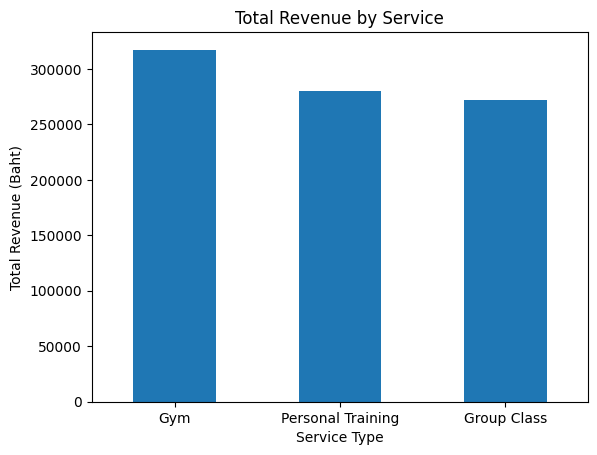

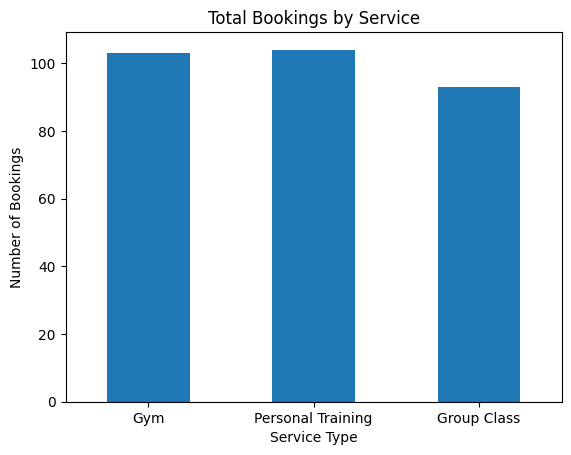

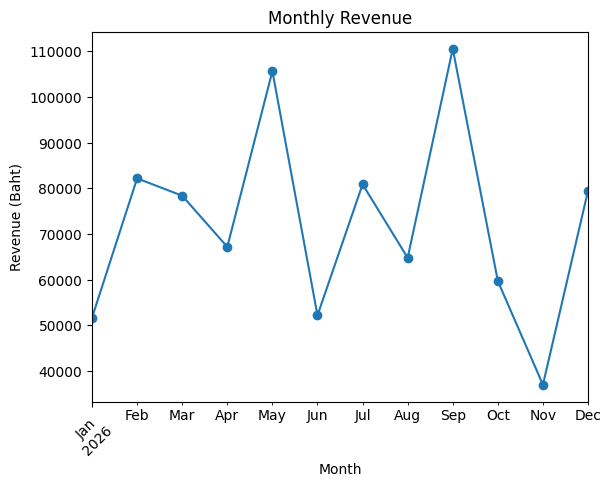

In [29]:
# ============================================
# PART 8 : DATA VISUALIZATION
# ============================================


# --------------------------------------------
# GRAPH 1
# Total Revenue by Service
# --------------------------------------------

q1_pandas.plot(kind="bar", y="total_revenue", legend=False)

plt.title("Total Revenue by Service")

plt.xlabel("Service Type")

plt.ylabel("Total Revenue (Baht)")

plt.xticks(rotation=0)

plt.show()


# --------------------------------------------
# GRAPH 2
# Total Bookings by Service
# --------------------------------------------

q2_pandas.plot(kind="bar", y="total_bookings", legend=False)

plt.title("Total Bookings by Service")

plt.xlabel("Service Type")

plt.ylabel("Number of Bookings")

plt.xticks(rotation=0)

plt.show()


# --------------------------------------------
# GRAPH 3
# Monthly Revenue
# --------------------------------------------

membership_df["booking_date"] = pd.to_datetime(membership_df["booking_date"])

monthly_revenue = (membership_df.groupby(membership_df["booking_date"].dt.to_period("M"))["price"].sum())

monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue")

plt.xlabel("Month")

plt.ylabel("Revenue (Baht)")

plt.xticks(rotation=45)

plt.show()

In [30]:
# ============================================
# PART 9 : EXPORT CSV
# ============================================

membership_df.to_csv("gym_membership_data.csv", index=False, encoding="utf-8-sig")

print("Export CSV สำเร็จ")

Export CSV สำเร็จ


In [31]:
# ============================================
# PART 10 : INPUT NEW BOOKING + VIP DISCOUNT
# ============================================

def add_new_booking():
    global membership_df
    try:
        member_id = int(input("กรอก Member ID: "))
        if member_id not in member_data:
            print("❌ ไม่พบ Member ID")
            return

        selected_member = member_data[member_id]
        print("\nเลือก Package")

        for package in packages:
            print(
                f"{package.package_id} - "
                f"{package.package_name} "
                f"({package.price} บาท)"
            )


        package_id = int(input("กรอก Package ID: "))
        selected_package = find_package(package_id)

        if selected_package is None:
            return

        print("\nเลือก Service")

        for i, service in enumerate(services, start=1):

            print(f"{i} - {service}")


        service_choice = int(input("เลือก Service: "))

        if (service_choice < 1 or service_choice > len(services)):
            print("❌ เลือก Service ไม่ถูกต้อง")
            return

        hours = float(input("จำนวนชั่วโมง: "))

        if not validate_hours(hours):
            return


        # ------------------------------------
        # สร้าง Booking ID ใหม่
        # ------------------------------------

        new_booking_id = max([booking.booking_id for booking in memberships_300]) + 1


        # ------------------------------------
        # สร้าง Booking
        # ------------------------------------

        new_booking = MembershipPackage(booking_id=new_booking_id, member=selected_member, package=selected_package, hours=hours, service_type=services[service_choice - 1],booking_date=datetime.now())

        new_booking.mark_done()


        # ------------------------------------
        # คำนวณราคา VIP
        # ------------------------------------

        original_price = (new_booking.calculate_price())

        discount, final_price = (calculate_final_price(original_price, selected_member.is_vip))


        # ------------------------------------
        # เพิ่มลง List
        # ------------------------------------

        memberships_300.append(new_booking)


        # ------------------------------------
        # เพิ่มลง DataFrame
        # เพื่อให้ Dashboard เห็นข้อมูลใหม่
        # ------------------------------------

        new_data = pd.DataFrame([{

            "booking_id":new_booking.booking_id,

            "member_id":selected_member.member_id,

            "name":selected_member.name,

            "age":selected_member.age,

            "weight_kg":selected_member.weight_kg,

            "is_vip":selected_member.is_vip,

            "package_id":selected_package.package_id,

            "package_name":selected_package.package_name,

            # เก็บราคาสุทธิ
            "price":final_price,

            "hours":new_booking.hours,

            "service_type":new_booking.service_type,

            "booking_date":new_booking.booking_date,

            "status":new_booking.status
        }])


        membership_df = pd.concat([membership_df, new_data], ignore_index=True)


        # ------------------------------------
        # แสดงผล
        # ------------------------------------

        print("\n================================")

        print("       เพิ่มการจองสำเร็จ!")

        print("================================")

        print(
            f"Booking ID: "
            f"{new_booking_id}"
        )

        print(
            f"Member: "
            f"{selected_member.name}"
        )

        print(
            f"Package: "
            f"{selected_package.package_name}"
        )

        print(
            f"Service: "
            f"{new_booking.service_type}"
        )

        print(
            f"ราคาเต็ม: "
            f"{original_price:,.2f} บาท"
        )


        if selected_member.is_vip:

            print(
                "ส่วนลด VIP: "
                f"{discount:,.2f} บาท"
            )

        else:
            print("ส่วนลด: 0.00 บาท")


        print(
            f"ราคาสุทธิ: "
            f"{final_price:,.2f} บาท"
        )

        print(
            f"Status: "
            f"{new_booking.status}"
        )

        print("================================")


    except ValueError:
        print("❌ กรุณากรอกข้อมูลให้ถูกต้อง")

In [32]:
# ============================================
# PART 11 : SUMMARY REPORT
# ============================================

total_bookings = len(membership_df)

total_revenue = membership_df["price"].sum()

average_price = membership_df["price"].mean()

vip_bookings = membership_df["is_vip"].sum()


print(
    "================================"
)

print(
    "      GYM MEMBERSHIP REPORT"
)

print(
    "================================"
)

print(f"Total Bookings: {total_bookings}")

print(f"Total Revenue: {total_revenue:,.2f} Baht")

print(f"Average Price: {average_price:,.2f} Baht")

print(f"VIP Bookings: {vip_bookings}")

print(
    "================================"
)

      GYM MEMBERSHIP REPORT
Total Bookings: 300
Total Revenue: 869,900.00 Baht
Average Price: 2,899.67 Baht
VIP Bookings: 141


In [33]:
# ============================================
# PART 12 : SQLITE DATABASE
# ============================================

conn = sqlite3.connect("fitness_gym.db")


membership_df.to_sql("gym_memberships", conn, if_exists="replace", index=False)


print("บันทึกข้อมูลลง SQLite สำเร็จ")

บันทึกข้อมูลลง SQLite สำเร็จ


In [14]:
# ============================================
# PART 13 : SQL ANALYSIS
# ============================================


# --------------------------------------------
# QUESTION 1
# --------------------------------------------

q1_sql = pd.read_sql_query("""

    SELECT

        service_type,

        SUM(price)
        AS total_revenue

    FROM gym_memberships

    GROUP BY service_type

    ORDER BY total_revenue DESC

""", conn)


print(
    "QUESTION 1 - SQL"
)

display(q1_sql)


# --------------------------------------------
# QUESTION 2
# --------------------------------------------

q2_sql = pd.read_sql_query("""

    SELECT

        service_type,

        COUNT(booking_id)
        AS total_bookings,

        SUM(price)
        AS total_revenue

    FROM gym_memberships

    GROUP BY service_type

    ORDER BY total_revenue DESC

""", conn)


print(
    "QUESTION 2 - SQL"
)

display(q2_sql)


# --------------------------------------------
# QUESTION 3
# --------------------------------------------

q3_sql = pd.read_sql_query("""

    SELECT

        service_type,

        AVG(weight_kg)
        AS avg_weight

    FROM gym_memberships

    GROUP BY service_type

    ORDER BY avg_weight DESC

""", conn)


print(
    "QUESTION 3 - SQL"
)

display(q3_sql)

QUESTION 1 - SQL


,service_type,total_revenue
0,Gym,305800
1,Personal Training,297000
2,Group Class,259500


QUESTION 2 - SQL


,service_type,total_bookings,total_revenue
0,Gym,103,305800
1,Personal Training,105,297000
2,Group Class,92,259500


QUESTION 3 - SQL


,service_type,avg_weight
0,Group Class,75.302174
1,Personal Training,75.188571
2,Gym,73.068932


In [34]:
# ============================================
# PART 14 : BONUS
# DATABASE TABLES + JOIN
# ============================================


# --------------------------------------------
# MEMBERS
# --------------------------------------------

members_df = pd.DataFrame([{"member_id": member.member_id, "name": member.name, "age": member.age, "weight_kg": member.weight_kg, "is_vip": int(member.is_vip)} for member in members_300])


members_df.to_sql("members", conn, if_exists="replace", index=False)


# --------------------------------------------
# PACKAGES
# --------------------------------------------

packages_df = pd.DataFrame([package.get_package_info() for package in packages])


packages_df.to_sql("packages", conn, if_exists="replace", index=False)


# --------------------------------------------
# SERVICES
# --------------------------------------------

services_df = pd.DataFrame({"service_id": range(1, len(services) + 1), "service_name": services})


services_df.to_sql("services", conn, if_exists="replace", index=False)


# --------------------------------------------
# CREATE MEMBERSHIP TABLE
# --------------------------------------------

service_map = {service: i + 1 for i, service in enumerate(services)}

bookings_df = membership_df.copy()

bookings_df["service_id"] = (bookings_df["service_type"].map(service_map))

bookings_df = bookings_df[["booking_id", "member_id", "package_id", "service_id", "price", "hours", "booking_date", "status"]]


bookings_df.to_sql("membership_bookings", conn, if_exists="replace", index=False)


# --------------------------------------------
# JOIN 4 TABLES
# --------------------------------------------

join_result = pd.read_sql_query("""

    SELECT

        b.booking_id,

        m.name
        AS member_name,

        CASE

            WHEN m.is_vip = 1
            THEN 'VIP'

            ELSE 'General'

        END
        AS member_type,

        p.package_name,

        s.service_name,

        b.price,

        b.hours,

        b.booking_date,

        b.status

    FROM membership_bookings b

    JOIN members m

        ON b.member_id = m.member_id

    JOIN packages p

        ON b.package_id = p.package_id

    JOIN services s

        ON b.service_id = s.service_id

    ORDER BY b.booking_id

""", conn)


print(
    "JOIN 4 TABLES สำเร็จ"
)

display(join_result.head(10))

JOIN 4 TABLES สำเร็จ


,booking_id,member_name,member_type,package_name,service_name,price,hours,booking_date,status
0,1,ปุณณภา พัฒนานนท์,General,Premium,Group Class,2500,2.0,2026-09-05 00:00:00,Completed
1,2,สุภัสสรา บุญญฤทธิ์,VIP,Basic,Group Class,1200,3.0,2026-12-02 00:00:00,Completed
2,3,ชลธิชา รุ่งเรือง,General,Premium,Gym,2500,1.5,2026-01-08 00:00:00,Completed
3,4,ปุณณภา วัฒนชัย,General,Basic,Group Class,1200,3.0,2026-02-20 00:00:00,Completed
4,5,ธีรภัทร ศรีวัฒนานนท์,General,Basic,Personal Training,1200,1.0,2026-11-19 00:00:00,Completed
5,6,สิรวิชญ์ พัฒนกุล,VIP,Premium,Personal Training,2500,3.0,2026-05-07 00:00:00,Completed
6,7,รัชชานนท์ รุ่งเรือง,VIP,Basic,Personal Training,1200,2.5,2026-11-29 00:00:00,Completed
7,8,ธนภัทร พงศ์ไพบูลย์,General,Premium,Group Class,2500,2.5,2026-05-17 00:00:00,Completed
8,9,ณัฐวุฒิ สุวรรณดี,General,Premium,Group Class,2500,2.5,2026-08-05 00:00:00,Completed
9,10,ณัฐธิดา เจริญสุข,General,Premium,Personal Training,2500,1.0,2026-07-25 00:00:00,Completed


In [35]:
# ============================================
# PART 15 : VIP DISCOUNT
# ============================================

VIP_DISCOUNT = 0.10


def calculate_final_price(price, is_vip):
    if is_vip:
        discount = (price * VIP_DISCOUNT)
    else:
        discount = 0

    final_price = (price - discount)

    return (round(discount, 2), round(final_price, 2))


discount_data = []


for booking in memberships_300:
    original_price = (booking.calculate_price())
    discount, final_price = (calculate_final_price(original_price, booking.member.is_vip))

    discount_data.append({

        "booking_id":booking.booking_id,

        "member_name":booking.member.name,

        "member_type":

            "VIP"

            if booking.member.is_vip

            else "General", "service_type":booking.service_type, "original_price":original_price, "discount":discount, "final_price":final_price
})


discount_df = pd.DataFrame(discount_data)


discount_summary = (discount_df.groupby("member_type").agg(total_bookings=("booking_id", "count"),total_original_price=("original_price", "sum"), total_discount=("discount", "sum"), total_final_price=("final_price", "sum")))

print("VIP DISCOUNT SUMMARY")

display(discount_summary)

VIP DISCOUNT SUMMARY


,total_bookings,total_original_price,total_discount,total_final_price
member_type,,,,
General,159,439600,0.0,439600.0
VIP,141,430300,43030.0,387270.0


In [36]:
vip_discount_sql = pd.read_sql_query("""

    SELECT

        b.booking_id,

        m.name
        AS member_name,

        CASE

            WHEN m.is_vip = 1
            THEN 'VIP'

            ELSE 'General'

        END
        AS member_type,

        b.price
        AS original_price,

        CASE

            WHEN m.is_vip = 1
            THEN b.price * 0.10

            ELSE 0

        END
        AS discount,

        CASE

            WHEN m.is_vip = 1
            THEN b.price * 0.90

            ELSE b.price

        END
        AS final_price

    FROM membership_bookings b

    JOIN members m

        ON b.member_id = m.member_id

    ORDER BY b.booking_id

""", conn)


display(vip_discount_sql.head(10))

,booking_id,member_name,member_type,original_price,discount,final_price
0,1,ปุณณภา พัฒนานนท์,General,2500,0.0,2500.0
1,2,สุภัสสรา บุญญฤทธิ์,VIP,1200,120.0,1080.0
2,3,ชลธิชา รุ่งเรือง,General,2500,0.0,2500.0
3,4,ปุณณภา วัฒนชัย,General,1200,0.0,1200.0
4,5,ธีรภัทร ศรีวัฒนานนท์,General,1200,0.0,1200.0
5,6,สิรวิชญ์ พัฒนกุล,VIP,2500,250.0,2250.0
6,7,รัชชานนท์ รุ่งเรือง,VIP,1200,120.0,1080.0
7,8,ธนภัทร พงศ์ไพบูลย์,General,2500,0.0,2500.0
8,9,ณัฐวุฒิ สุวรรณดี,General,2500,0.0,2500.0
9,10,ณัฐธิดา เจริญสุข,General,2500,0.0,2500.0


In [37]:
# ============================================
# PART 16 : ERROR HANDLING
# ============================================

def find_member(member_id):
    try:
        member_id = int(member_id)
    except ValueError:
        print("Member ID ต้องเป็นตัวเลข")
        return None

    if member_id not in member_data:
        print(f"ไม่พบ Member ID: {member_id}")
        return None
    return member_data[member_id]


def find_package(package_id):
    try:
        package_id = int(package_id)
    except ValueError:
        print("Package ID ต้องเป็นตัวเลข")
        return None


    for package in packages:
        if (package.package_id == package_id):
            return package

    print(f"ไม่พบ Package ID: {package_id}")

    return None


def validate_hours(hours):
    try:
        hours = float(hours)
    except ValueError:
        print("จำนวนชั่วโมงต้องเป็นตัวเลข")
        return False


    if hours <= 0:
        print("จำนวนชั่วโมงต้องมากกว่า 0")
        return False


    if hours > 12:
        print("ไม่สามารถจองเกิน 12 ชั่วโมง")
        return False
    return True


print(
    "===== ERROR HANDLING TEST ====="
)

find_member(999999)

find_package(999999)

validate_hours(-5)

print(validate_hours(2))

===== ERROR HANDLING TEST =====
ไม่พบ Member ID: 999999
ไม่พบ Package ID: 999999
จำนวนชั่วโมงต้องมากกว่า 0
True


In [38]:
# ============================================
# PART 17 : FITNESS DASHBOARD
# DAILY / WEEKLY / MONTHLY
# ============================================

def dashboard_report(report_type):
    data = membership_df.copy()
    data["booking_date"] = (pd.to_datetime(data["booking_date"]))


    # ========================================
    # DAILY
    # ========================================

    if report_type == "1":
        date_input = input("กรอกวันที่ (YYYY-MM-DD): ").strip()

        try:
            selected_date = (pd.to_datetime(date_input, format="%Y-%m-%d"))

        except ValueError:
            print("รูปแบบวันที่ไม่ถูกต้อง")
            return

        report = data[data["booking_date"].dt.date == selected_date.date()]


        title = (f"วันที่ {selected_date.date()}")


    # ========================================
    # WEEKLY
    # ========================================

    elif report_type == "2":

        date_input = input(
            "กรอกวันที่ในสัปดาห์ (YYYY-MM-DD): "
        ).strip()


        try:
            selected_date = (pd.to_datetime(date_input, format="%Y-%m-%d"))
        except ValueError:
            print("รูปแบบวันที่ไม่ถูกต้อง")
            return


        start_date = (selected_date - pd.Timedelta(days=selected_date.weekday()))


        end_date = (start_date + pd.Timedelta(days=6))

        report = data[(data["booking_date"] >= start_date) & (data["booking_date"] < end_date + pd.Timedelta(days=1))]

        title = (

            f"สัปดาห์ "

            f"{start_date.date()} "

            f"ถึง "

            f"{end_date.date()}"
        )


    # ========================================
    # MONTHLY
    # ========================================

    elif report_type == "3":
        try:
            year = int(input("กรอกปี: "))
            month = int(input("กรอกเดือน (1-12): "))

        except ValueError:
            print("กรุณากรอกตัวเลข")
            return

        if month < 1 or month > 12:
            print("เดือนไม่ถูกต้อง")
            return


        report = data[(data["booking_date"].dt.year == year) & (data["booking_date"].dt.month == month)]

        title = (f"เดือน {month}/{year}")

    else:
        print("กรุณาเลือก 1, 2 หรือ 3")
        return


    # ========================================
    # SUMMARY
    # ========================================

    total_bookings = len(
        report
    )


    total_revenue = report[
        "price"
    ].sum()


    average_revenue = (report["price"].mean() if total_bookings > 0 else 0)

    vip_count = (report["is_vip"].sum() if total_bookings > 0 else 0)

    general_count = (total_bookings - vip_count)


    print(
        "\n===================================="
    )

    print(
        "    FITNESS MEMBERSHIP DASHBOARD"
    )

    print(
        "===================================="
    )

    print(f"ช่วงเวลา: {title}")

    print(f"จำนวนการจอง: {total_bookings}")

    print(f"รายได้รวม: {total_revenue:,.2f} บาท")

    print(f"รายได้เฉลี่ย: {average_revenue:,.2f} บาท")

    print(f"VIP: {vip_count}")

    print(f"General: {general_count}")

    print(
        "===================================="
    )


    if total_bookings > 0:

        service_summary = (report.groupby("service_type").agg(bookings=("booking_id", "count"),revenue=("price", "sum")).sort_values("revenue", ascending=False))

        print("\nSERVICE SUMMARY")

        display(service_summary)

    else:
        print("\nไม่มีข้อมูลในช่วงเวลาที่เลือก")


# ============================================
# DASHBOARD MENU
# ============================================

def dashboard_menu():
    while True:

        print(
            "\n=============================="
        )

        print(
            "      FITNESS DASHBOARD"
        )

        print(
            "=============================="
        )

        print("1. รายวัน")

        print("2. รายสัปดาห์")

        print("3. รายเดือน")

        print("0. ออกจาก Dashboard")

        choice = input("เลือกช่วงเวลา: ").strip()

        if choice == "0":
            print("ออกจาก Dashboard")
            break

        dashboard_report(choice)

In [20]:
main_menu()